## Cas concret avec l'expérience

Dans cette partie on reprends le bon Hamiltonien, c'est à dire : 
$$
\begin{align*}
\dfrac{\partial \mathcal{H}}{\partial p_x} &=& \dfrac{eB v_F^2 p_x}{c\varepsilon(p)} \\
\dfrac{\partial \mathcal{H}}{\partial p_y} &=& \dfrac{eB}{c}\left( \dfrac{v_F^2 p_y}{\varepsilon(p)}+ v_d\right)
\end{align*}
$$

Posons $G:=\dfrac{\Delta t eB \ v_F^2}{c \ \varepsilon(p)}$, alors comme dans le cas jouet on peut réécrire le schéma symplectique :
$$
P^{n+1} = \begin{bmatrix} 1 -G^2 & G \\ -G & 1 \end{bmatrix} \times P^n + \begin{bmatrix} \dfrac{\Delta t \ eB}{c} v_d \\ 0 \end{bmatrix}
$$


In [ ]:
# Packages ------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pyhamsys import HamSys, solve_ivp_sympext, Parameters

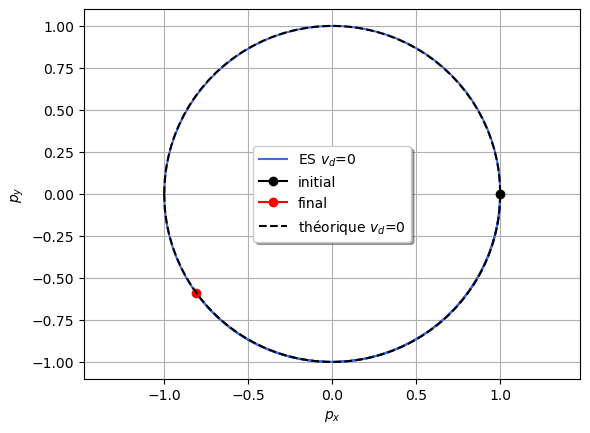

In [16]:
# Euler Symplictique Définition -----------------------------
""" Ce schéma n'est correct que pour l'Hamiltonien défini par le papier de Sergey Krishtopenko. """
def varepsilon(p):
    M = 13/1000 #valeur au hasard
    vF = 1 #pareil
    px = p[0]
    py = p[1]
    return np.sqrt(M**2 + vF**2 * (px**2 + py**2))

def ES(deltaT, T, P, e, B, Vf, c, varepsi, vd):
    '''
    deltaT = Pas de temps
    T : temps final
    e : charge de l'électron
    B : champs magnétique       # prendre .7
    Vf : vitesse de fermi
    c : vitesse de la lumière
    varepsi : fonction bande qui dépend de P
    vd: vitesse drift (E/B)
    '''

    P_trajectory = [P]
    t = 0
    while ( t + deltaT < T):
            
        G = (deltaT * e * B * Vf**2) / (c * varepsi(P))
        Iteration_matrix = [[1 - G**2, G], [-G, 1]]
        Drift_matrix = [deltaT * e * B * vd /c, 0]    
        P = Iteration_matrix @ P + Drift_matrix
        t += deltaT
        P_trajectory.append(P)

    deltaT = T - t
    G = (deltaT * e * B * Vf**2) / (c * varepsi(P))
    Iteration_matrix = [[1 - G**2, G], [-G, 1]]
    P = Iteration_matrix @ P + Drift_matrix
    P_trajectory.append(P)
    return np.array(P_trajectory)
# test ---choix des valeurs au hasard-----------------------------------------------------
T = 4* np.pi
P = np.array([1, 0])
e = 1
B = 0.7
Vf = 1
c = 1
vd = 0# 0.1
deltaT = 0.01

# ----------------------------------------------
traj_ES = ES(deltaT, T, P, e, B, Vf, c, varepsilon, vd)
plt.plot(traj_ES[:, 0], traj_ES[:,1], color='royalblue',label=fr'ES $v_d$={vd}')
plt.plot(traj_ES[0,0], traj_ES[0, 1], color='black', marker='o', label='initial')
plt.plot(traj_ES[-1,0], traj_ES[-1, 1], color='red', marker='o', label='final')

x = np.linspace(-1, 1, 500)
plt.plot(x, np.sqrt(1-x**2), color='black', linestyle='--', label=r'théorique $v_d$=0')
plt.plot(x, -np.sqrt(1-x**2), color='black', linestyle='--')

plt.legend(shadow=True)
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_y$')
plt.axis('equal')
plt.grid()
plt.show()



### Bande Fermions de Dirac et Graphène $G0$
On compare le résultat précédent avec les résultats obtenus avec des méthodes de la libraire PyHamSys.
Puis on ajoute un méthode pour faire la même chose avec une bande de graphène G0 (identique à ce qu'on utilise pour le code "streaming example")

        Computation finished in 0 seconds


Choix système : p_system


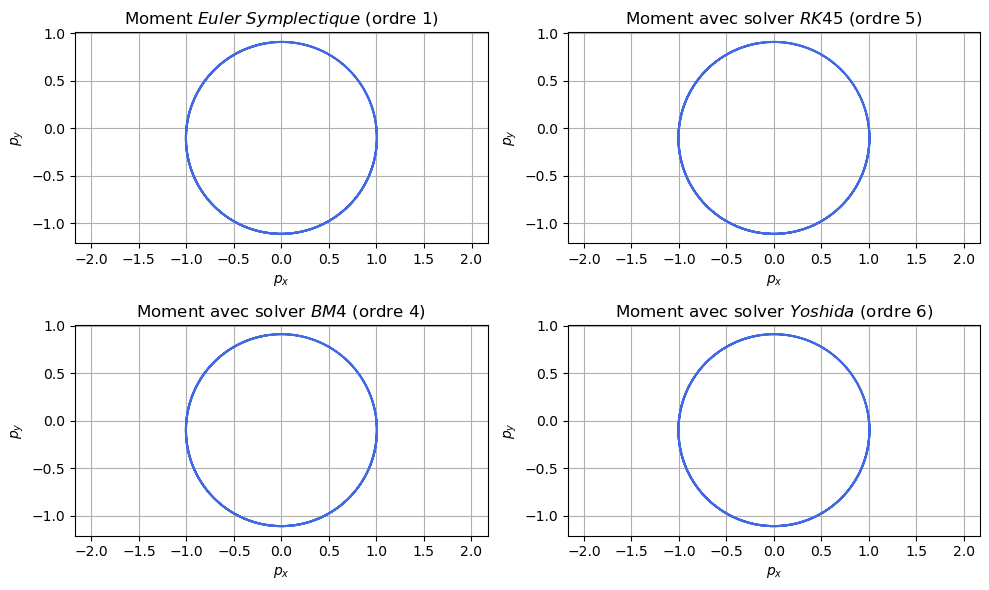

        Computation finished in 0 seconds


Choix système : y_dot_G0


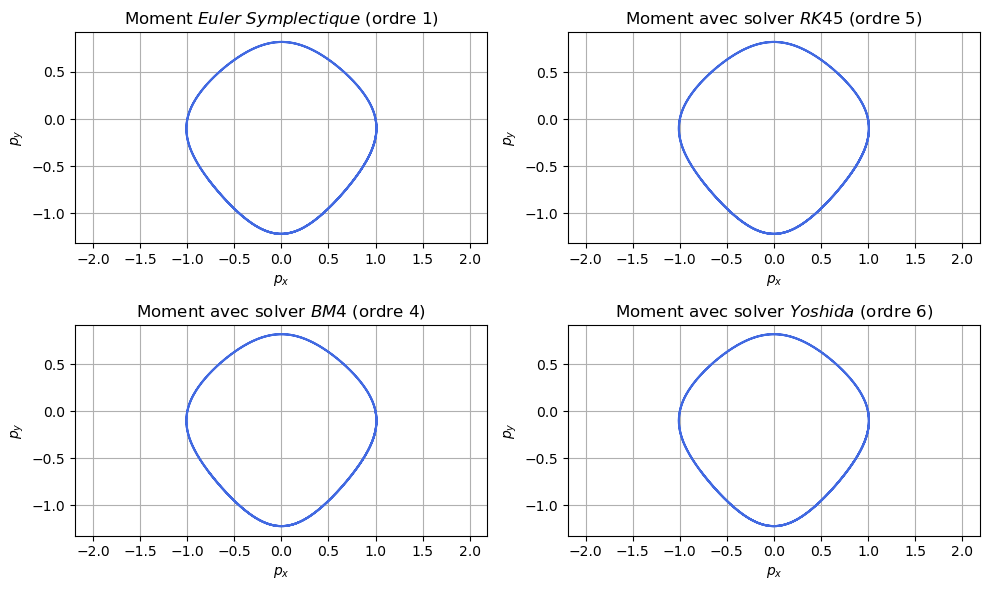

In [15]:
# Code avec PyHamSys ------------------------
# (Cette cellule utilise du code de la cellule précédente)

# Hamiltonien Défintion
hs = HamSys(ndof=1)

deltaT = 0.01
T = 4 * 2 * np.pi 
time_range = np.arange(0, T + deltaT , deltaT) #On dépasse un peu le temps final.
P = np.array([1, 0])
e = 1
B = 0.7
vF = 1
c = 1
vd = 0.1 #5.0
# ------------------------------------------------------------------------

def p_system(t, P): #resolution papier
    G1 = ( e * B * vF**2) / (c * varepsilon(P)) 
    G2 = (e * B / c)
    q, p = np.split(P, 2)
    y0 = G2 * ((vF**2 * p / varepsilon(P)) + vd) 
    y1 = -G1 * q

    return np.concatenate((y0, y1), axis=None)

def y_dot_G0(t, y):   # for graphene (benoit)
    q, p = y[0], y[1]
    y0 =    p * (1+q*q)/2+ vd
    y1 =   -q*  (1+p*p)/2
    return np.array([y0, y1])

# ES_graphene ---------------------------------------------------------
def ES_graphene(deltaT, T, P, vd):
    '''
    deltaT = Pas de temps
    vd: vitesse drift (e/B)
    '''
    P_trajectory = [P]
    t = 0
    lmbda = deltaT / 2

    while ( t + deltaT < T):
        A, B = P[0], P[1]
        Y = B - lmbda * (A + A * B**2)
        discriminant = 1 - 4 * lmbda * Y * ( lmbda * Y + A + deltaT * vd)
        X1 = (1 + np.sqrt(discriminant)) / (2 * lmbda * Y)
        X2 = (1 - np.sqrt(discriminant)) / (2 * lmbda * Y)

        '''
        Pour le choix de X j'ai d'abord choisi de prendre le plus petit de façon arbitraire.
        Ensuite j'ai voulu regarder laquelle des deux valeurs est la plus proche de l'anciene et en comparant avec l'ancienne méthode on retrouve le même résultat.
        On trouve un résulat proche des solveurs de PyHamsys.
        Si l'on prend seulement la racine X1 il y a des erreurs et je ne sais pas pourquoi, je dois regarder en détail.
        '''

        X = X1 if abs(X1 - A) < abs(X2 - A) else X2
        P = [X, Y]
        # P_test = [X2, Y]
        t += deltaT
        P_trajectory.append(P)

    # print(f'C\'est tout le temps X2 qu\'on prend ? Réponse : {P_test == P} ')
    deltaT = T - t
    A, B = P[0], P[1]
    Y = B - lmbda * (A + A * B**2)
    discriminant = 1 - 4 * lmbda * Y * ( lmbda * Y + A + deltaT * vd)
    X1 = (1 + np.sqrt(discriminant)) / (2 * lmbda * Y)
    X2 = (1 - np.sqrt(discriminant)) / (2 * lmbda * Y)
    X = X1 if abs(X1 - A) < abs(X2 - A) else X2
    P = [X, Y]
    P_trajectory.append(P)
    return np.array(P_trajectory)

# resolution ---------------------------------------------------------

system_liste = [p_system, y_dot_G0]
for i, name in enumerate(system_liste):
    hs.y_dot = name # choix du système
    sol_BM4 = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='BM4'))
    # sol_Verlet = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='Verlet'))
    sol_Yoshida = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='Yos6'))
    if i == 0:
        Moment_ES = ES(deltaT, T, P, e, B, vF, c, varepsilon, vd)
    else :
        Moment_ES_graphene = ES_graphene(deltaT, T, P, vd)
    
    sol_RK45 = hs.integrate( P, time_range, params=Parameters(step=deltaT, solver='RK45'))
    # Plot ------------------------------------------
    print(f'Choix système : {name.__name__}')
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,6))
    if i == 0:
        ax1.plot(Moment_ES[:, 0], Moment_ES[:,1], color='royalblue',label='ES')
        ax1.set_xlabel(r'$p_x$')
        ax1.set_ylabel(r'$p_y$')
        ax1.set_title(r'Moment $Euler \ Symplectique$ (ordre 1)')
        
    else :
        ax1.plot(Moment_ES_graphene[:, 0], Moment_ES_graphene[:,1] ,color='royalblue',label='ES')
        # ax1.plot(Moment_ES_graphene[-1, 0], Moment_ES_graphene[-1, 1], marker='o', color='red',label='Dernier')
        # ax1.plot(Moment_ES_graphene[-2, 0], Moment_ES_graphene[-2,1], marker='o', color='black',label='Avant-Dernier')
        ax1.set_xlabel(r'$p_x$')
        ax1.set_ylabel(r'$p_y$')
        ax1.set_title(r'Moment $Euler \ Symplectique$ (ordre 1)')        

    ax2.plot(sol_RK45.y[0], sol_RK45.y[1], color='royalblue')
    ax2.set_xlabel(r'$p_x$')
    ax2.set_ylabel(r'$p_y$')
    ax2.set_title(r'Moment avec solver $RK45$ (ordre 5)')
    

    ax3.plot(sol_BM4.y[0], sol_BM4.y[1], color='royalblue')
    ax3.set_xlabel(r'$p_x$')
    ax3.set_ylabel(r'$p_y$')
    ax3.set_title(r'Moment avec solver $BM4$ (ordre 4)')
    
    

    ax4.plot(sol_Yoshida.y[0], sol_Yoshida.y[1], color='royalblue')
    ax4.set_xlabel(r'$p_x$')
    ax4.set_ylabel(r'$p_y$')
    ax4.set_title(r'Moment avec solver $Yoshida$ (ordre 6)')
    ax1.grid(), ax2.grid(), ax3.grid(), ax4.grid()
    ax1.axis('equal'), ax2.axis('equal'), ax3.axis('equal'), ax4.axis('equal')
    plt.tight_layout()
    plt.show()

# print(f'Avant dernier point ES_graphène : [{np.round(Moment_ES_graphene[-2, 0], 3)},  {np.round(Moment_ES_graphene[-2,1],3)}] ')
# print(f'Avant Dernier point RK45 : [ {np.round(sol_RK45.y[0][-2],3)}, {np.round(sol_RK45.y[1][-2],3)} ] ')
# print(f'Avant Dernier point BM4 : [ {np.round(sol_BM4.y[0][-2],3)}, {np.round(sol_BM4.y[1][-2], 3)} ] ')
# print(f'Avant Dernier point Yoshida: [ {np.round(sol_Yoshida.y[0][-2],3)}, {np.round(sol_Yoshida.y[1][-2], 3)} ] ')

# print(f'Dernier point ES_graphène : [{np.round(Moment_ES_graphene[-1, 0], 3)},  {np.round(Moment_ES_graphene[-1,1],3)}] ')
# print(f'Dernier point RK45 : [ {np.round(sol_RK45.y[0][-1],3)}, {np.round(sol_RK45.y[1][-1],3)} ] ')
# print(f'Dernier point BM4 : [ {np.round(sol_BM4.y[0][-1],3)}, {np.round(sol_BM4.y[1][-1],3)} ] ')
# print(f'Dernier point Yoshida: [ {np.round(sol_Yoshida.y[0][-1],3)}, {np.round(sol_Yoshida.y[1][-1], 3)} ] ')
